# 📊 Projeto Interdisciplinar — Ciência de Dados
## Entrega 1: Preparação e Exploração de Dados

**Objetivo:** Fundação do projeto — coleta, exploração e processamento dos dados brutos para criação de um Dashboard de suporte à tomada de decisão estratégica e operacional.

---
### Fontes de Dados
| Arquivo | Descrição |
|---|---|
| `CAMPAIGN.CSV` | Campanhas de marketing enviadas |
| `CAMPAIGNxORDER.CSV` | Relacionamento entre campanhas e pedidos |
| `CUSTOMER.CSV` | Cadastro de clientes |
| `CUSTOMERADDRESS.CSV` | Endereços dos clientes |
| `STORE.csv` | Cadastro de lojas |
| `STOREORDER.csv` | Pedidos realizados nas lojas |
| `TEMPLATE.csv` | Templates utilizados nas campanhas |

---
## 0. Instalação e Importação de Bibliotecas

In [3]:
# Instalação de bibliotecas adicionais (caso necessário)
# !pip install pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')
PALETTE = 'Blues_d'

print(' Bibliotecas importadas com sucesso!')

 Bibliotecas importadas com sucesso!


---
## 1. Coleta Inicial — Importação dos Dados

In [4]:
# ──────────────────────────────────────────────────────────────────
# OPÇÃO A — Google Colab: faça o upload dos arquivos CSV e
#            ajuste os caminhos abaixo para o diretório correto.
#
# from google.colab import files
# uploaded = files.upload()  # selecione todos os CSVs
#
# OPÇÃO B — Caminhos locais já definidos (ajuste se necessário)
# ──────────────────────────────────────────────────────────────────

BASE_PATH = ''

def load(filename, **kwargs):
    """Carrega um CSV com tratamento de erros e exibe resumo."""
    path = BASE_PATH + filename
    df = pd.read_csv(path, on_bad_lines='skip', **kwargs)
    print(f'  ✔ {filename:<30} → {df.shape[0]:>7} linhas × {df.shape[1]} colunas')
    return df

print('📥 Importando bases de dados...\n')
df_campaign       = load('CAMPAIGN.CSV')
df_camp_order     = load('CAMPAIGNxORDER.CSV')
df_customer       = load('CUSTOMER.CSV')
df_address        = load('CUSTOMERADDRESS.CSV')
df_store          = load('STORE.csv')
df_order          = load('STOREORDER.csv')
df_template       = load('TEMPLATE.csv')

print('\n Todas as bases carregadas!')

📥 Importando bases de dados...

  ✔ CAMPAIGN.CSV                   →   56461 linhas × 10 colunas
  ✔ CAMPAIGNxORDER.CSV             →   95284 linhas × 9 colunas
  ✔ CUSTOMER.CSV                   →  160710 linhas × 13 colunas
  ✔ CUSTOMERADDRESS.CSV            →  159550 linhas × 7 colunas
  ✔ STORE.csv                      →      77 linhas × 9 colunas
  ✔ STOREORDER.csv                 →  118936 linhas × 13 colunas
  ✔ TEMPLATE.csv                   →     348 linhas × 6 colunas

 Todas as bases carregadas!


---
## 2. Descrição dos Dados — Dicionário de Variáveis

In [5]:
def describe_df(name, df):
    print(f'\n{'='*65}')
    print(f'  📋  {name}')
    print(f'{'='*65}')
    print(f'  Dimensões : {df.shape[0]} linhas × {df.shape[1]} colunas')
    summary = pd.DataFrame({
        'Tipo'       : df.dtypes,
        'Não-Nulos'  : df.notna().sum(),
        'Nulos'      : df.isna().sum(),
        '% Nulo'     : (df.isna().mean() * 100).round(1),
        'Únicos'     : df.nunique()
    })
    display(summary)

datasets = {
    'CAMPAIGN'        : df_campaign,
    'CAMPAIGNxORDER'  : df_camp_order,
    'CUSTOMER'        : df_customer,
    'CUSTOMERADDRESS' : df_address,
    'STORE'           : df_store,
    'STOREORDER'      : df_order,
    'TEMPLATE'        : df_template,
}

for name, df in datasets.items():
    describe_df(name, df)


  📋  CAMPAIGN
  Dimensões : 56461 linhas × 10 colunas


,Tipo,Não-Nulos,Nulos,% Nulo,Únicos
segmentid,object,56001,460,0.8,121
templateid,object,55169,1292,2.3,127
storeid,object,56461,0,0.0,38
name,object,56461,0,0.0,134
description,object,45282,11179,19.8,86
type,int64,56461,0,0.0,3
statusend,int64,56461,0,0.0,5
createdat,object,56461,0,0.0,147
customerid,object,56461,0,0.0,19395
sendat,object,56461,0,0.0,56338



  📋  CAMPAIGNxORDER
  Dimensões : 95284 linhas × 9 colunas


,Tipo,Não-Nulos,Nulos,% Nulo,Únicos
campaignid,object,95284,0,0.0,125
message_id,object,95284,0,0.0,30628
sent_at,object,95284,0,0.0,30556
status,int64,95284,0,0.0,2
order_at,object,95284,0,0.0,24144
storeid,object,95284,0,0.0,29
customerid,object,95284,0,0.0,8773
order_id,object,95284,0,0.0,24147
totalamount,float64,95284,0,0.0,5416



  📋  CUSTOMER
  Dimensões : 160710 linhas × 13 colunas


...

,Tipo,Não-Nulos,Nulos,% Nulo,Únicos
id,object,77,0,0.0,77
name,object,77,0,0.0,77
complement,object,13,64,83.1,11
neighborhood,float64,0,77,100.0,0
city,object,5,72,93.5,2
state,object,5,72,93.5,2
zipcode,float64,23,54,70.1,20
status,int64,77,0,0.0,1
createdat,object,77,0,0.0,77



  📋  STOREORDER
  Dimensões : 118936 linhas × 13 colunas


,Tipo,Não-Nulos,Nulos,% Nulo,Únicos
id,object,118936,0,0.0,118936
storeid,object,118936,0,0.0,43
customerid,object,118936,0,0.0,51859
scheduledat,object,118936,0,0.0,118911
totalamount,float64,118936,0,0.0,12894
subtotalamount,float64,118936,0,0.0,9527
discountamount,float64,118936,0,0.0,2027
taxamount,float64,118936,0,0.0,424
saleschannel,object,118936,0,0.0,11
status,int64,118936,0,0.0,20



  📋  TEMPLATE
  Dimensões : 348 linhas × 6 colunas


,Tipo,Não-Nulos,Nulos,% Nulo,Únicos
id,object,348,0,0.0,348
storeid,object,348,0,0.0,63
name,object,348,0,0.0,187
description,object,273,75,21.6,111
createdat,object,348,0,0.0,346
createdby,object,348,0,0.0,26


In [6]:
# Estatísticas descritivas das variáveis numéricas
print('\n📊 Estatísticas descritivas — STOREORDER (valores financeiros):')
display(df_order[['totalamount','subtotalamount','discountamount','taxamount']].describe().round(2))

print('\n📊 Estatísticas descritivas — CAMPAIGNxORDER (totalamount):')
display(df_camp_order[['totalamount']].describe().round(2))


📊 Estatísticas descritivas — STOREORDER (valores financeiros):


,totalamount,subtotalamount,discountamount,taxamount
count,118936.00,118936.00,118936.00,118936.00
mean,57.33,55.99,5.42,6.79
std,55.96,55.42,6.66,4.52
min,0.00,0.00,0.00,0.00
25%,31.89,31.10,0.00,3.49
50%,45.91,44.90,3.15,6.98
75%,69.88,67.80,10.00,9.89
max,10000.00,10000.00,368.00,43.84



📊 Estatísticas descritivas — CAMPAIGNxORDER (totalamount):


,totalamount
count,95284.00
mean,61.33
std,89.95
min,0.00
25%,35.00
50%,51.89
75%,73.80
max,10000.00


---
## 3. Exploração (EDA) — Análise Visual e Comportamento da Base

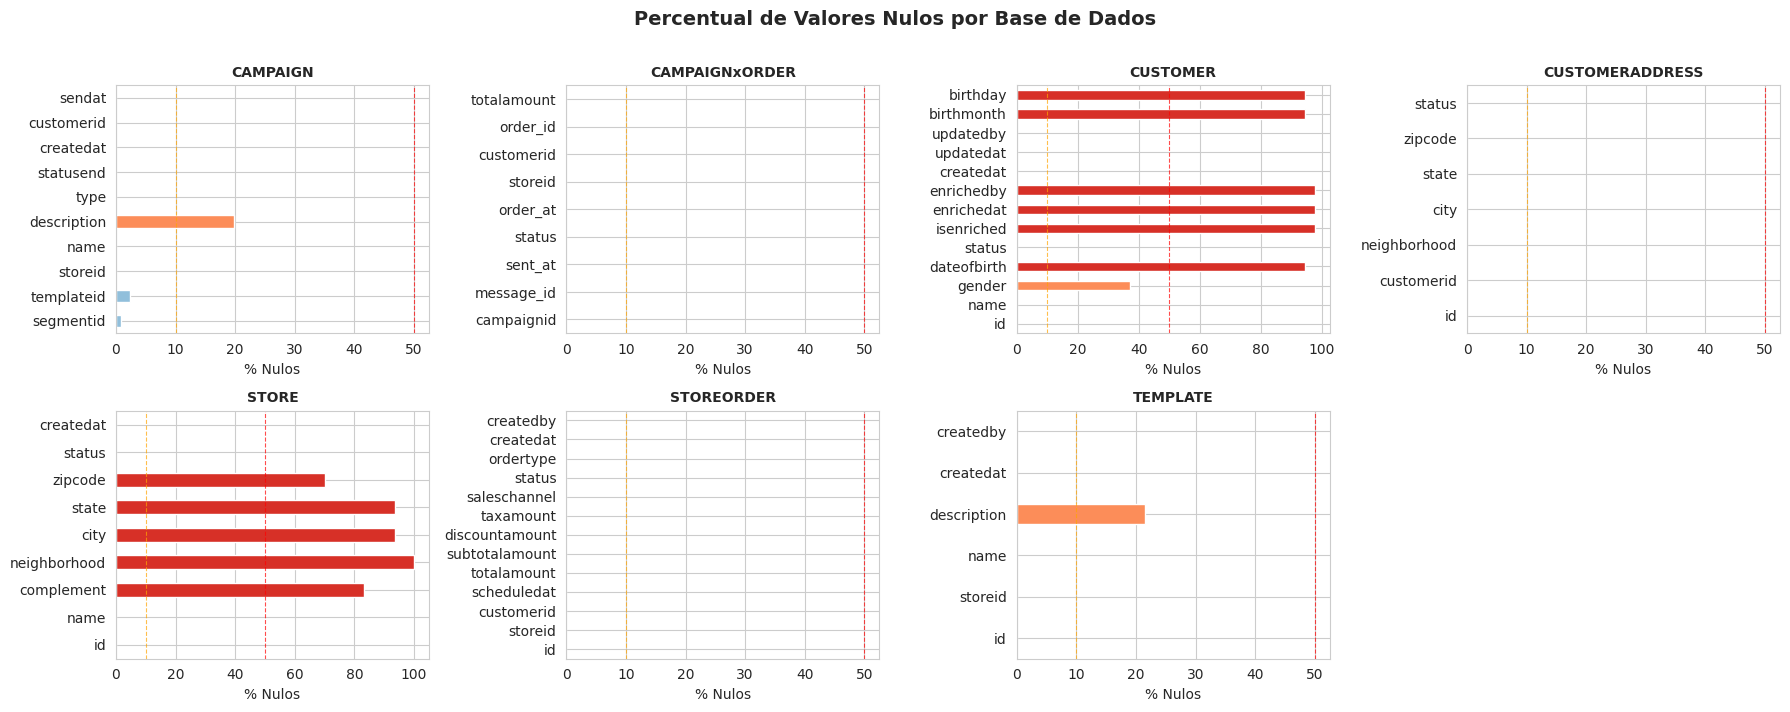

In [7]:
# ── 3.1  Mapa de calor de nulos por base ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    null_pct = df.isna().mean() * 100
    colors = ['#d73027' if v > 50 else '#fc8d59' if v > 10 else '#91bfdb' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('% Nulos')
    ax.axvline(x=10, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(x=50, color='red',    linestyle='--', linewidth=0.8, alpha=0.7)

# Oculta o subplot extra
axes[-1].set_visible(False)
fig.suptitle('Percentual de Valores Nulos por Base de Dados', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

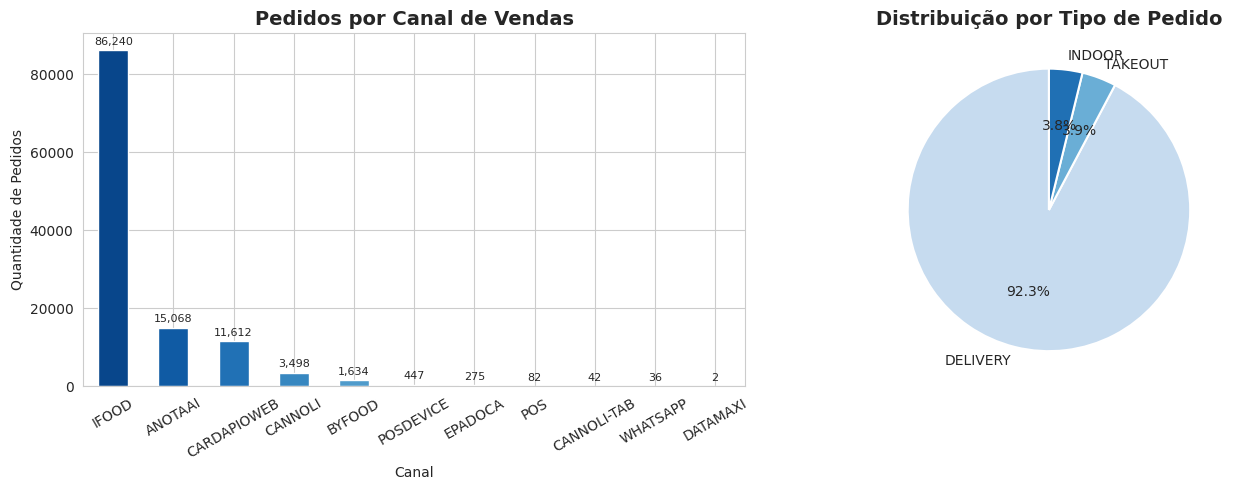

In [8]:
# ── 3.2  Distribuição de pedidos por canal de vendas ──────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

canal = df_order['saleschannel'].value_counts()
canal.plot(kind='bar', ax=ax1, color=sns.color_palette('Blues_r', len(canal)), edgecolor='white')
ax1.set_title('Pedidos por Canal de Vendas')
ax1.set_xlabel('Canal')
ax1.set_ylabel('Quantidade de Pedidos')
ax1.tick_params(axis='x', rotation=30)
for bar in ax1.patches:
    ax1.annotate(f'{int(bar.get_height()):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=8)

tipo = df_order['ordertype'].value_counts()
tipo.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=sns.color_palette('Blues', len(tipo)),
          startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Distribuição por Tipo de Pedido')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

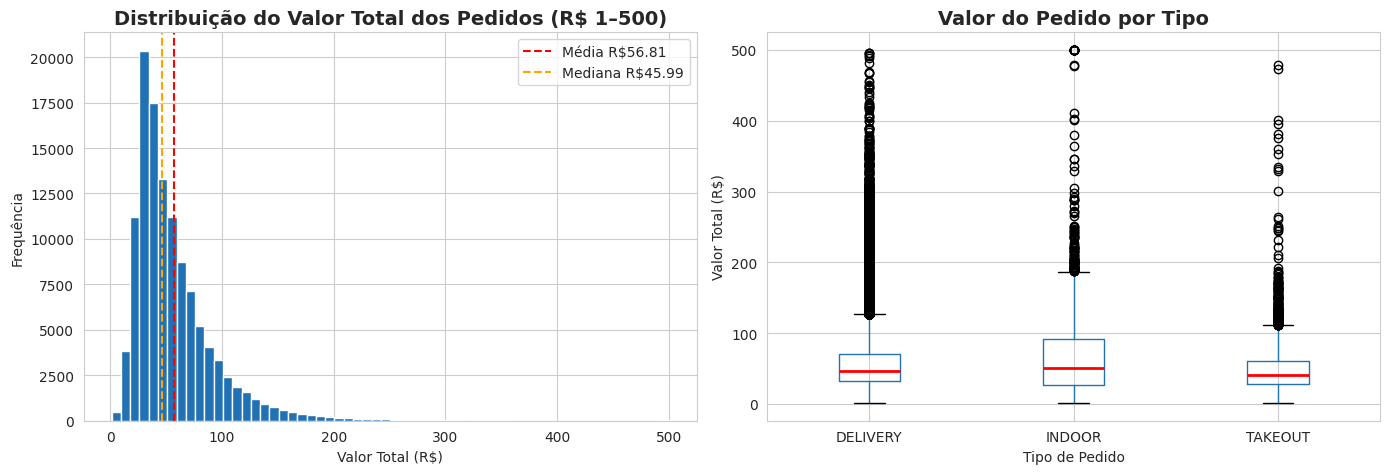

In [9]:
# ── 3.3  Distribuição do valor total dos pedidos ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Filtra outliers extremos para melhor visualização
orders_clean = df_order[df_order['totalamount'].between(1, 500)]
orders_clean['totalamount'].hist(bins=60, ax=ax1, color='#2171b5', edgecolor='white')
ax1.set_title('Distribuição do Valor Total dos Pedidos (R$ 1–500)')
ax1.set_xlabel('Valor Total (R$)')
ax1.set_ylabel('Frequência')
ax1.axvline(orders_clean['totalamount'].mean(),   color='red',    linestyle='--', label=f'Média R${orders_clean["totalamount"].mean():.2f}')
ax1.axvline(orders_clean['totalamount'].median(), color='orange', linestyle='--', label=f'Mediana R${orders_clean["totalamount"].median():.2f}')
ax1.legend()

# Boxplot por tipo de pedido
orders_clean.boxplot(column='totalamount', by='ordertype', ax=ax2,
                     boxprops=dict(color='#2171b5'),
                     medianprops=dict(color='red', linewidth=2))
ax2.set_title('Valor do Pedido por Tipo')
ax2.set_xlabel('Tipo de Pedido')
ax2.set_ylabel('Valor Total (R$)')
plt.suptitle('')

plt.tight_layout()
plt.show()

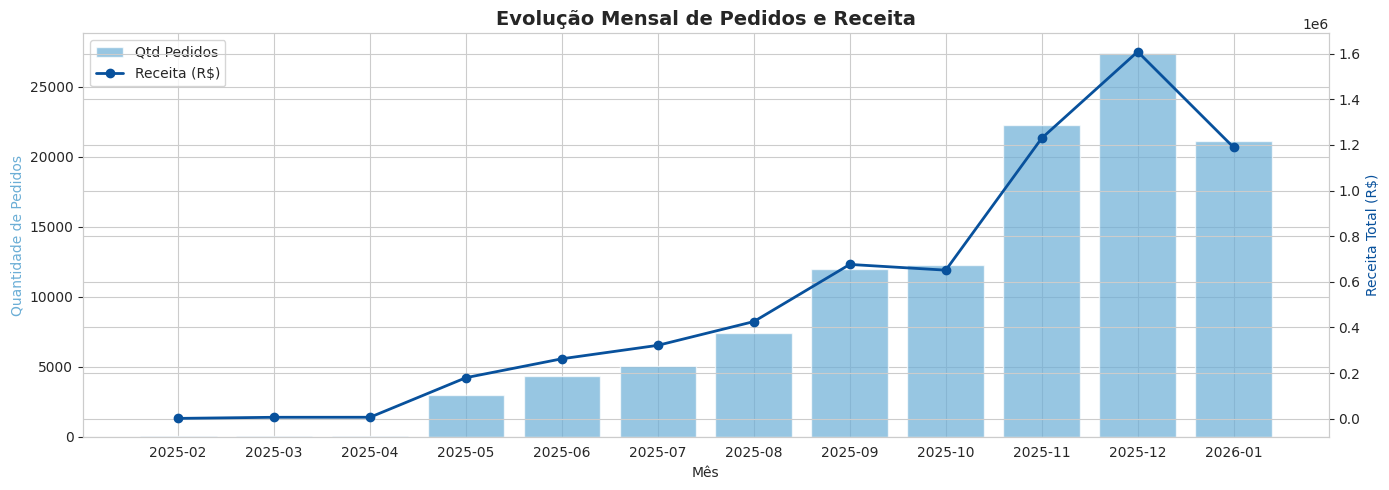

In [10]:
# ── 3.4  Pedidos ao longo do tempo ───────────────────────────────
df_order['createdat_dt'] = pd.to_datetime(df_order['createdat'], utc=True, errors='coerce')
df_order['yearmonth'] = df_order['createdat_dt'].dt.to_period('M')

monthly = df_order.groupby('yearmonth').agg(
    pedidos=('id', 'count'),
    receita=('totalamount', 'sum')
).reset_index()
monthly['yearmonth_str'] = monthly['yearmonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['yearmonth_str'], monthly['pedidos'], color='#6baed6', label='Qtd Pedidos', alpha=0.7)
ax2.plot(monthly['yearmonth_str'], monthly['receita'], color='#08519c', marker='o', linewidth=2, label='Receita (R$)')

ax1.set_xlabel('Mês')
ax1.set_ylabel('Quantidade de Pedidos', color='#6baed6')
ax2.set_ylabel('Receita Total (R$)', color='#08519c')
plt.title('Evolução Mensal de Pedidos e Receita')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

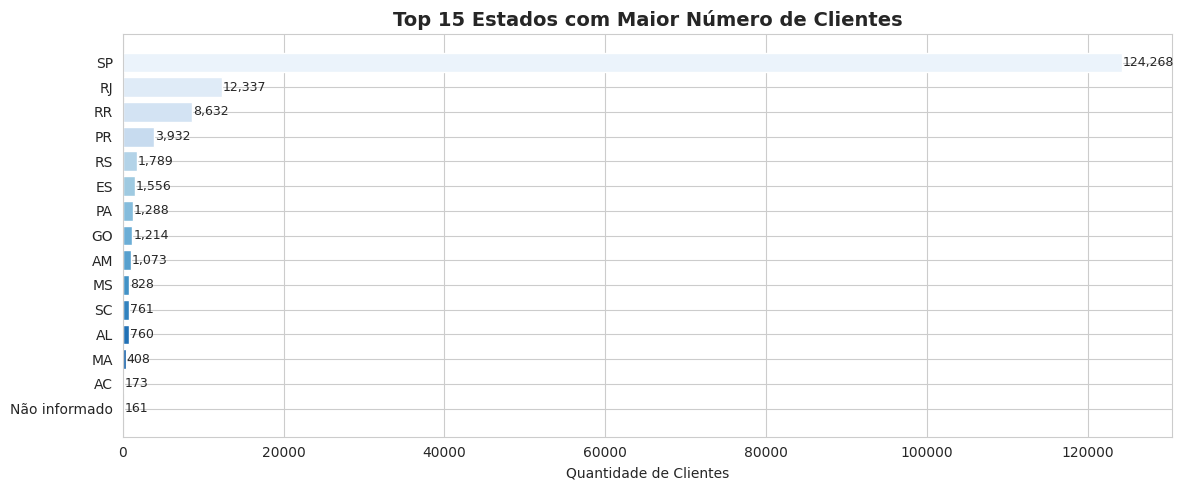

In [11]:
# ── 3.5  Distribuição geográfica de clientes por estado ──────────
estado_dist = df_address['state'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(estado_dist.index[::-1], estado_dist.values[::-1],
               color=sns.color_palette('Blues_r', len(estado_dist)), edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_title('Top 15 Estados com Maior Número de Clientes')
ax.set_xlabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

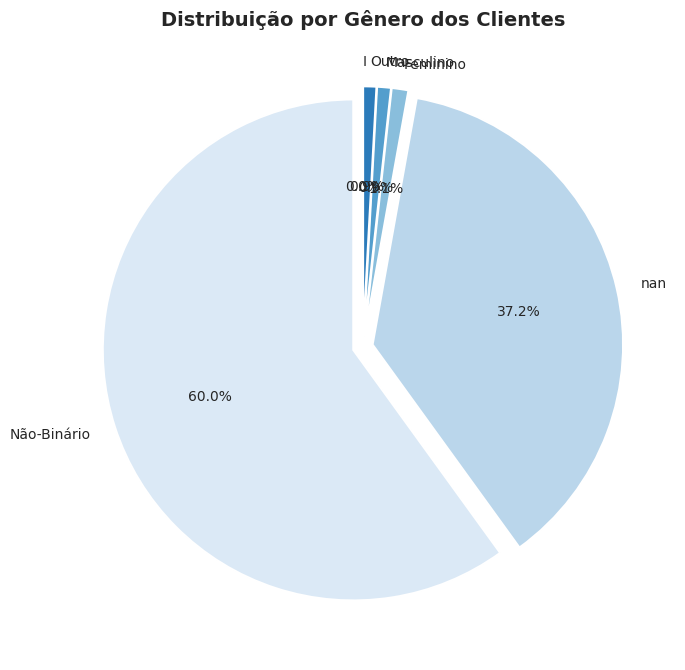

In [12]:
# ── 3.6  Gênero dos clientes ─────────────────────────────────────
genero = df_customer['gender'].value_counts(dropna=False)
genero.index = genero.index.map(lambda x: {'M': 'Masculino', 'F': 'Feminino',
                                             'N': 'Não-Binário', 'O': 'Outro',
                                             'NaN': 'Não Informado'}.get(str(x), str(x)))

fig, ax = plt.subplots(figsize=(7, 7))
explode = [0.04] * len(genero)
genero.plot(kind='pie', ax=ax, autopct='%1.1f%%',
            colors=sns.color_palette('Blues', len(genero)),
            explode=explode, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Distribuição por Gênero dos Clientes')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

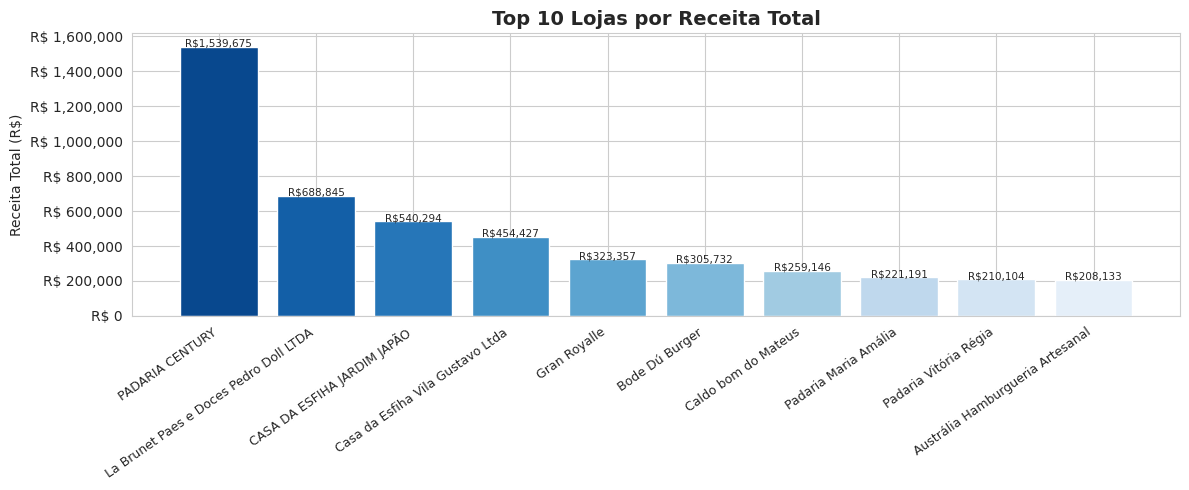

In [13]:
# ── 3.7  Top lojas por receita ────────────────────────────────────
top_stores = (
    df_order.groupby('storeid')['totalamount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .merge(df_store[['id', 'name']], left_on='storeid', right_on='id', how='left')
)
top_stores['label'] = top_stores['name'].fillna(top_stores['storeid'].str[:8])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top_stores)), top_stores['totalamount'],
              color=sns.color_palette('Blues_r', len(top_stores)), edgecolor='white')
ax.set_xticks(range(len(top_stores)))
ax.set_xticklabels(top_stores['label'], rotation=35, ha='right', fontsize=9)
ax.set_title('Top 10 Lojas por Receita Total')
ax.set_ylabel('Receita Total (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'R${bar.get_height():,.0f}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

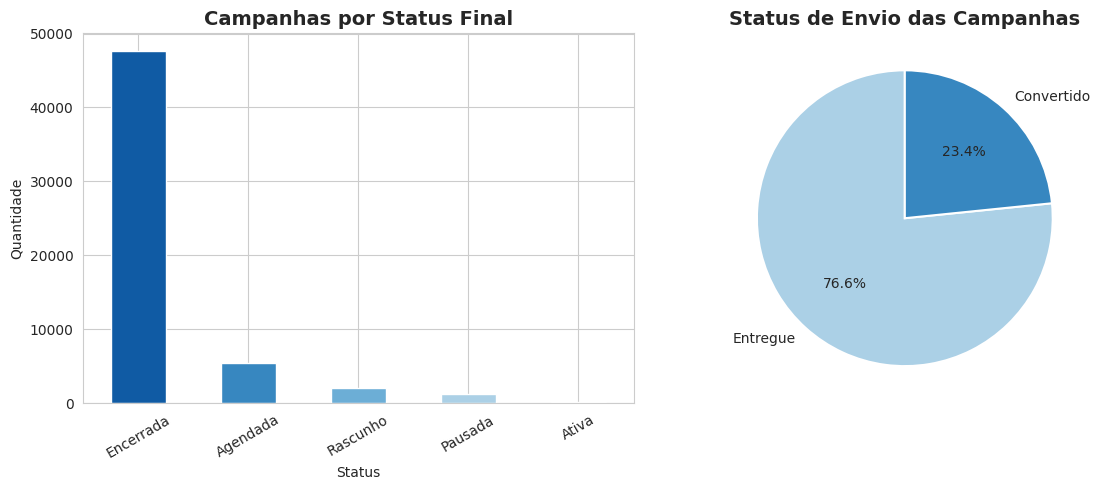

In [14]:
# ── 3.8  Status das campanhas ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

status_map = {1: 'Ativa', 2: 'Encerrada', 3: 'Cancelada', 4: 'Agendada',
              5: 'Pausada', 6: 'Erro', 7: 'Rascunho'}

camp_status = df_campaign['statusend'].map(status_map).value_counts()
camp_status.plot(kind='bar', ax=ax1, color=sns.color_palette('Blues_r', len(camp_status)), edgecolor='white')
ax1.set_title('Campanhas por Status Final')
ax1.set_xlabel('Status')
ax1.set_ylabel('Quantidade')
ax1.tick_params(axis='x', rotation=30)

order_status = df_camp_order['status'].map({2: 'Entregue', 3: 'Aberto', 4: 'Convertido'}).value_counts()
order_status.plot(kind='pie', ax=ax2, autopct='%1.1f%%',
                  colors=sns.color_palette('Blues', len(order_status)),
                  startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Status de Envio das Campanhas')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

---
## 4. Processamento e Engenharia de Dados

### 4.1 Seleção de Colunas Relevantes

In [15]:
# ── STOREORDER: colunas relevantes para o dashboard ──────────────
order_sel = df_order[[
    'id', 'storeid', 'customerid', 'scheduledat',
    'totalamount', 'subtotalamount', 'discountamount',
    'saleschannel', 'ordertype', 'status', 'createdat'
]].copy()

# ── CUSTOMER: colunas relevantes ─────────────────────────────────
customer_sel = df_customer[[
    'id', 'name', 'gender', 'dateofbirth', 'status', 'createdat'
]].copy()

# ── CAMPAIGN: colunas relevantes ─────────────────────────────────
campaign_sel = df_campaign[[
    'segmentid', 'templateid', 'storeid', 'name',
    'type', 'statusend', 'createdat', 'customerid', 'sendat'
]].copy()

# ── CAMPAIGNxORDER: mantém todas as colunas (já enxuta) ──────────
camporder_sel = df_camp_order.copy()

print(' Seleção de colunas concluída!')
print(f'  STOREORDER  : {order_sel.shape}')
print(f'  CUSTOMER    : {customer_sel.shape}')
print(f'  CAMPAIGN    : {campaign_sel.shape}')
print(f'  CAMP×ORDER  : {camporder_sel.shape}')

 Seleção de colunas concluída!
  STOREORDER  : (118936, 11)
  CUSTOMER    : (160710, 6)
  CAMPAIGN    : (56461, 9)
  CAMP×ORDER  : (95284, 9)


### 4.2 Limpeza e Uniformização

In [16]:
# ── Conversão de datas ────────────────────────────────────────────
date_cols_order = ['scheduledat', 'createdat']
for col in date_cols_order:
    order_sel[col] = pd.to_datetime(order_sel[col], utc=True, errors='coerce').dt.tz_localize(None)

customer_sel['createdat']  = pd.to_datetime(customer_sel['createdat'],  utc=True, errors='coerce').dt.tz_localize(None)
customer_sel['dateofbirth'] = pd.to_datetime(customer_sel['dateofbirth'], errors='coerce')

campaign_sel['createdat'] = pd.to_datetime(campaign_sel['createdat'], utc=True, errors='coerce').dt.tz_localize(None)
campaign_sel['sendat']    = pd.to_datetime(campaign_sel['sendat'],    utc=True, errors='coerce').dt.tz_localize(None)

camporder_sel['sent_at']  = pd.to_datetime(camporder_sel['sent_at'], utc=True, errors='coerce').dt.tz_localize(None)
camporder_sel['order_at'] = pd.to_datetime(camporder_sel['order_at'], utc=True, errors='coerce').dt.tz_localize(None)

# ── Remoção de duplicatas ─────────────────────────────────────────
for name, df in [('STOREORDER', order_sel), ('CUSTOMER', customer_sel),
                 ('CAMPAIGN', campaign_sel), ('CAMP×ORDER', camporder_sel)]:
    antes = len(df)
    df.drop_duplicates(inplace=True)
    depois = len(df)
    print(f'  {name:<12}: {antes - depois} duplicatas removidas → {depois} registros')

# ── Normalização de texto ─────────────────────────────────────────
customer_sel['name']   = customer_sel['name'].str.strip().str.title()
customer_sel['gender'] = customer_sel['gender'].str.upper().str.strip()
order_sel['saleschannel'] = order_sel['saleschannel'].str.upper().str.strip()
order_sel['ordertype']    = order_sel['ordertype'].str.upper().str.strip()

# ── Tratamento de valores nulos ───────────────────────────────────
# Clientes sem gênero: preenche com 'NÃO INFORMADO'
customer_sel['gender'] = customer_sel['gender'].fillna('NI')

# Pedidos com totalamount == 0: tratados como inválidos
print(f'\n  Pedidos com totalamount = 0: {(order_sel["totalamount"] == 0).sum()}')
order_sel = order_sel[order_sel['totalamount'] > 0].copy()

print('\n Limpeza e uniformização concluídas!')

  STOREORDER  : 0 duplicatas removidas → 118936 registros
  CUSTOMER    : 0 duplicatas removidas → 160710 registros
  CAMPAIGN    : 36 duplicatas removidas → 56425 registros
  CAMP×ORDER  : 0 duplicatas removidas → 95284 registros

  Pedidos com totalamount = 0: 314

 Limpeza e uniformização concluídas!


### 4.3 Derivação — Engenharia de Novas Features

In [17]:
from datetime import date

TODAY = pd.Timestamp(date.today())

# ── Clientes: idade e faixa etária ───────────────────────────────
customer_sel['age'] = ((TODAY - customer_sel['dateofbirth']).dt.days / 365.25).round().astype('Int64')

def faixa_etaria(age):
    if pd.isna(age): return 'Não Informado'
    if age < 18:  return 'Menor de 18'
    if age < 25:  return '18–24'
    if age < 35:  return '25–34'
    if age < 45:  return '35–44'
    if age < 55:  return '45–54'
    if age < 65:  return '55–64'
    return '65+'

customer_sel['age_group'] = customer_sel['age'].apply(faixa_etaria)

# ── Pedidos: colunas temporais derivadas ─────────────────────────
order_sel['year']     = order_sel['createdat'].dt.year
order_sel['month']    = order_sel['createdat'].dt.month
order_sel['month_name'] = order_sel['createdat'].dt.strftime('%b %Y')
order_sel['weekday']  = order_sel['createdat'].dt.day_name()
order_sel['hour']     = order_sel['createdat'].dt.hour
order_sel['is_weekend'] = order_sel['createdat'].dt.dayofweek >= 5

# ── Pedidos: flag de desconto aplicado ───────────────────────────
order_sel['has_discount'] = order_sel['discountamount'] > 0

# ── Pedidos: ticket médio por loja (métrica derivada) ────────────
ticket_medio = order_sel.groupby('storeid')['totalamount'].mean().rename('avg_ticket')
order_sel = order_sel.merge(ticket_medio, on='storeid', how='left')

# ── Campanhas: tempo entre criação e envio (dias) ─────────────────
campaign_sel['days_to_send'] = (
    campaign_sel['sendat'] - campaign_sel['createdat']
).dt.days

print(' Features derivadas criadas!')
print('\n  Novas colunas em CUSTOMER:', ['age', 'age_group'])
print('  Novas colunas em STOREORDER:', ['year','month','month_name','weekday','hour','is_weekend','has_discount','avg_ticket'])
print('  Novas colunas em CAMPAIGN:', ['days_to_send'])

 Features derivadas criadas!

  Novas colunas em CUSTOMER: ['age', 'age_group']
  Novas colunas em STOREORDER: ['year', 'month', 'month_name', 'weekday', 'hour', 'is_weekend', 'has_discount', 'avg_ticket']
  Novas colunas em CAMPAIGN: ['days_to_send']


### 4.4 Integração — Joins entre as Bases

In [18]:
# ── Tabela principal de pedidos enriquecida ───────────────────────
# STOREORDER ← STORE (nome da loja)
orders_full = order_sel.merge(
    df_store[['id', 'name']].rename(columns={'id': 'storeid', 'name': 'store_name'}),
    on='storeid', how='left'
)

# ← CUSTOMER (nome e dados do cliente)
orders_full = orders_full.merge(
    customer_sel[['id','name','gender','age','age_group']].rename(columns={'id':'customerid','name':'customer_name'}),
    on='customerid', how='left'
)

# ← CUSTOMERADDRESS (estado do cliente)
addr_agg = df_address.groupby('customerid')[['city','state']].first().reset_index()
orders_full = orders_full.merge(addr_agg, on='customerid', how='left')

print(f' Tabela principal de pedidos: {orders_full.shape}')
print('  Colunas disponíveis:', list(orders_full.columns))

 Tabela principal de pedidos: (118622, 26)
  Colunas disponíveis: ['id', 'storeid', 'customerid', 'scheduledat', 'totalamount', 'subtotalamount', 'discountamount', 'saleschannel', 'ordertype', 'status', 'createdat', 'year', 'month', 'month_name', 'weekday', 'hour', 'is_weekend', 'has_discount', 'avg_ticket', 'store_name', 'customer_name', 'gender', 'age', 'age_group', 'city', 'state']


In [23]:
# ── Tabela de desempenho de campanhas ─────────────
# CAMPAIGNxORDER ← CAMPAIGN ← TEMPLATE ← STORE

# The original 'campaign_sel' from 'cell-select' is missing the 'id' column,
# which is crucial for joining with 'camporder_sel' on 'campaignid'.
# To fix this within this cell, we'll re-select relevant columns from df_campaign,
# ensuring 'segmentid' (as the likely campaign ID) is included and 'days_to_send' is correctly calculated for the join.

campaign_details_for_merge = df_campaign[[
    'segmentid', 'templateid', 'storeid', 'name',
    'type', 'statusend', 'createdat', 'customerid', 'sendat'
]].copy()

campaign_details_for_merge['createdat'] = pd.to_datetime(campaign_details_for_merge['createdat'], utc=True, errors='coerce').dt.tz_localize(None)
campaign_details_for_merge['sendat'] = pd.to_datetime(campaign_details_for_merge['sendat'], utc=True, errors='coerce').dt.tz_localize(None)
campaign_details_for_merge['days_to_send'] = (
    campaign_details_for_merge['sendat'] - campaign_details_for_merge['createdat']
).dt.days

campaign_perf = camporder_sel.merge(
    campaign_details_for_merge[['segmentid', 'name', 'type', 'statusend', 'sendat', 'days_to_send']].rename(
        columns={'segmentid': 'campaign_id_for_merge', 'name': 'campaign_name'}),
    left_on='campaignid',
    right_on='campaign_id_for_merge',
    how='left'
).drop(columns=['campaign_id_for_merge'])

# Now, merge the campaign_perf with df_store to get store names
campaign_perf = campaign_perf.merge(
    df_store[['id','name']].rename(columns={'id':'store_id_for_merge', 'name':'store_name'}),
    left_on='storeid',
    right_on='store_id_for_merge',
    how='left'
).drop(columns=['store_id_for_merge'])

# Mapeamento de status
campaign_perf['status_label'] = campaign_perf['status'].map(
    {2: 'Entregue', 3: 'Aberto', 4: 'Convertido'})

print(f' Tabela de campanhas: {campaign_perf.shape}')
print('  Colunas:', list(campaign_perf.columns))

 Tabela de campanhas: (95284, 16)
  Colunas: ['campaignid', 'message_id', 'sent_at', 'status', 'order_at', 'storeid', 'customerid', 'order_id', 'totalamount', 'campaign_name', 'type', 'statusend', 'sendat', 'days_to_send', 'store_name', 'status_label']


### 4.5 Formatação Final — Dados Prontos para Visualização

In [24]:
# ── KPIs resumo ──────────────────────────────────────────────────
kpis = {
    'Total de Pedidos'            : len(orders_full),
    'Receita Total (R$)'          : orders_full['totalamount'].sum(),
    'Ticket Médio (R$)'           : orders_full['totalamount'].mean(),
    'Clientes Únicos'             : orders_full['customerid'].nunique(),
    'Lojas Ativas'                : orders_full['storeid'].nunique(),
    'Total de Campanhas'          : len(campaign_sel),
    'Campanhas Convertidas'       : (campaign_perf['status'] == 4).sum(),
    'Taxa de Conversão Campanhas' : f"{(campaign_perf['status'] == 4).mean() * 100:.1f}%",
    'Desconto Médio Aplicado (R$)': orders_full.loc[orders_full['has_discount'],'discountamount'].mean(),
    '% Pedidos c/ Desconto'       : f"{orders_full['has_discount'].mean()*100:.1f}%",
}

print('\n' + '='*55)
print('  📊  KPIs GERAIS DO DASHBOARD')
print('='*55)
for k, v in kpis.items():
    if isinstance(v, float):
        print(f'  {k:<38}: R$ {v:>10,.2f}')
    elif isinstance(v, int):
        print(f'  {k:<38}: {v:>12,}')
    else:
        print(f'  {k:<38}: {v:>12}')
print('='*55)


  📊  KPIs GERAIS DO DASHBOARD
  Total de Pedidos                      :      118,622
  Receita Total (R$)                    : R$ 6,818,316.81
  Ticket Médio (R$)                     : R$      57.48
  Clientes Únicos                       :       51,843
  Lojas Ativas                          :           43
  Total de Campanhas                    :       56,425
  Campanhas Convertidas                 :        22284
  Taxa de Conversão Campanhas           :        23.4%
  Desconto Médio Aplicado (R$)          : R$      10.50
  % Pedidos c/ Desconto                 :        51.7%


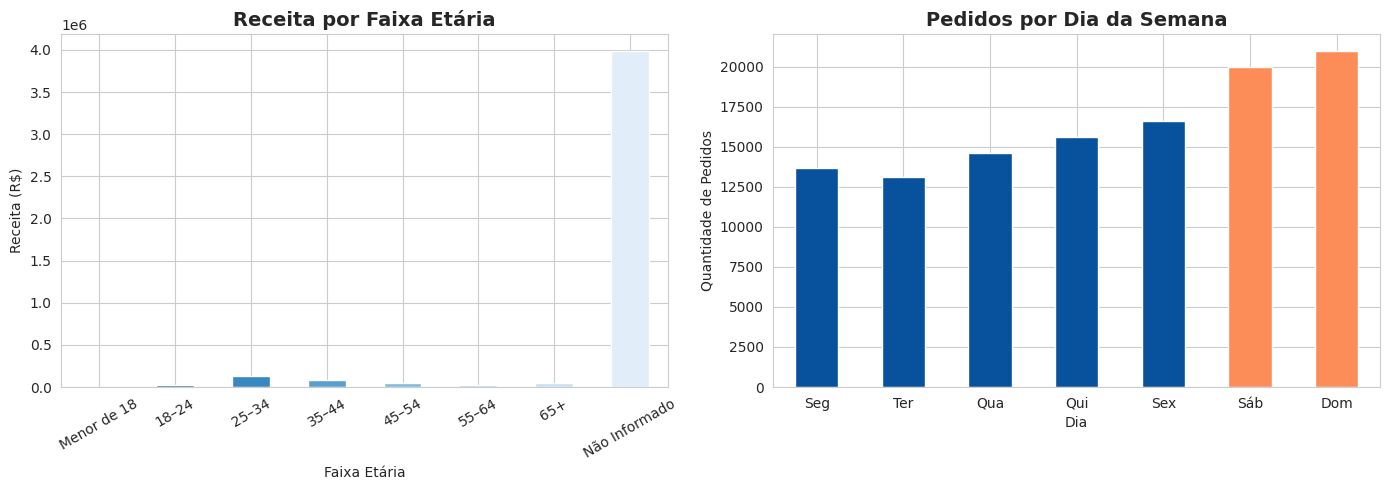

In [25]:
# ── Visualização final: faixa etária × receita ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

age_order_cats = ['Menor de 18','18–24','25–34','35–44','45–54','55–64','65+','Não Informado']

age_receita = (
    orders_full.groupby('age_group')['totalamount']
    .agg(['sum','count'])
    .reindex([c for c in age_order_cats if c in orders_full['age_group'].unique()])
)

age_receita['sum'].plot(kind='bar', ax=ax1, color=sns.color_palette('Blues_r', len(age_receita)), edgecolor='white')
ax1.set_title('Receita por Faixa Etária')
ax1.set_xlabel('Faixa Etária')
ax1.set_ylabel('Receita (R$)')
ax1.tick_params(axis='x', rotation=30)

# Pedidos por dia da semana
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_labels = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
wday = orders_full['weekday'].value_counts().reindex(weekday_order)
colors = ['#08519c' if i < 5 else '#fc8d59' for i in range(7)]
wday.plot(kind='bar', ax=ax2, color=colors, edgecolor='white')
ax2.set_xticklabels(weekday_labels, rotation=0)
ax2.set_title('Pedidos por Dia da Semana')
ax2.set_xlabel('Dia')
ax2.set_ylabel('Quantidade de Pedidos')

plt.tight_layout()
plt.show()

In [26]:
# ── Exportação dos dados processados ─────────────────────────────
orders_full.to_csv('orders_processed.csv', index=False)
campaign_perf.to_csv('campaign_perf.csv', index=False)
customer_sel.to_csv('customers_processed.csv', index=False)

print(' Arquivos exportados com sucesso!')
print('  📄 orders_processed.csv   →', orders_full.shape)
print('  📄 campaign_perf.csv      →', campaign_perf.shape)
print('  📄 customers_processed.csv→', customer_sel.shape)

 Arquivos exportados com sucesso!
  📄 orders_processed.csv   → (118622, 26)
  📄 campaign_perf.csv      → (95284, 16)
  📄 customers_processed.csv→ (160710, 8)


---
## Entrega 1 Concluída

| Etapa | Status |
|---|---|
| 1. Identificação e Coleta das Fontes | ✔ Concluído |
| 2. Descrição dos Dados (Dicionário) | ✔ Concluído |
| 3. Exploração (EDA) | ✔ Concluído |
| 4.1 Seleção de Colunas | ✔ Concluído |
| 4.2 Limpeza e Uniformização | ✔ Concluído |
| 4.3 Derivação de Features | ✔ Concluído |
| 4.4 Integração (Joins) | ✔ Concluído |
| 4.5 Formatação Final | ✔ Concluído |
